# Project Summary: Superstore Sales Data Analysis and Machine Learning Workflow

## Overview
This project presents a comprehensive analysis of Superstore sales data, following a complete data science workflow from ingestion to predictive modeling. The analysis delivers actionable business insights while demonstrating modern data science techniques.

## Key Components

### 1. Data Preparation
- Imported and cleaned structured retail data
- Handled missing values and duplicates
- Performed datetime parsing and type conversions
- Addressed outliers in Sales and Profit metrics
- Ensured data integrity through validation checks

### 2. Exploratory Analysis
- Identified top-performing products by profitability
- Analyzed sales trends across product categories
- Examined regional performance patterns
- Visualized data distributions and relationships

### 3. Feature Engineering
- Created time-based features from order/ship dates
- Calculated derived metrics like shipping duration
- Prepared data for machine learning applications

### 4. Predictive Modeling
- Developed regression models to predict profitability
- Implemented Linear Regression, Random Forest, and KNN algorithms
- Evaluated performance using R² and MSE metrics
- Applied k-fold cross-validation (k=5) for robust results

### 5. Business Insights
- Identified most profitable customer segments and product lines
- Analyzed discount impact on profit margins
- Provided data-driven recommendations for business optimization

## Technical Approach
The project showcases:
- Python data manipulation with Pandas
- Data visualization using Seaborn/Matplotlib
- Machine learning with scikit-learn
- Rigorous model evaluation techniques
- Clear communication of analytical findings

## Value Proposition
This analysis transforms raw sales data into actionable intelligence, demonstrating:
- How data science can drive retail business decisions
- Best practices in end-to-end analytical workflows
- The application of machine learning to real-world business problems

The clean, well-documented code and professional presentation make this project reproducible and adaptable for similar retail analytics challenges.

In [5]:
import pandas as pd
df=pd.read_csv('Superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Order Delivery (Days),Order Month/Year,Year,Ship Mode,Customer ID,Customer Name,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,3,Nov-16,2016,Second Class,CG-12520,Claire Gute,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,3,Nov-16,2016,Second Class,CG-12520,Claire Gute,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,4,Jun-16,2016,Second Class,DV-13045,Darrin Van Huff,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,7,Oct-15,2015,Standard Class,SO-20335,Sean O'Donnell,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,7,Oct-15,2015,Standard Class,SO-20335,Sean O'Donnell,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Row ID                 9994 non-null   int64  
 1   Order ID               9994 non-null   object 
 2   Order Date             9994 non-null   object 
 3   Ship Date              9994 non-null   object 
 4   Order Delivery (Days)  9994 non-null   int64  
 5   Order Month/Year       9994 non-null   object 
 6   Year                   9994 non-null   int64  
 7   Ship Mode              9994 non-null   object 
 8   Customer ID            9994 non-null   object 
 9   Customer Name          9994 non-null   object 
 10  Segment                9994 non-null   object 
 11  Country                9994 non-null   object 
 12  City                   9994 non-null   object 
 13  State                  9994 non-null   object 
 14  Postal Code            9994 non-null   int64  
 15  Regi

In [11]:
  # Drop duplicate rows
df = df.drop_duplicates()
    
    # Drop duplicates based on 'Order ID' and 'Product ID' if necessary
df = df.drop_duplicates(subset=['Order ID', 'Product ID'])
    
    # Remove rows with missing essential values
df = df.dropna(subset=['Order ID', 'Product ID', 'Customer ID', 'Sales', 'Profit'])
    
    # Convert 'Order Date' and 'Ship Date' to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
    
    # Remove rows where dates couldn't be converted
df = df.dropna(subset=['Order Date', 'Ship Date'])
    
    # Ensure numerical columns are correctly formatted
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
    
    # Handle incorrect or irrelevant data (e.g., negative profits if they should not exist)
df = df[df['Profit'] >= 0]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8116 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Row ID                 8116 non-null   int64         
 1   Order ID               8116 non-null   object        
 2   Order Date             8116 non-null   datetime64[ns]
 3   Ship Date              8116 non-null   datetime64[ns]
 4   Order Delivery (Days)  8116 non-null   int64         
 5   Order Month/Year       8116 non-null   object        
 6   Year                   8116 non-null   int64         
 7   Ship Mode              8116 non-null   object        
 8   Customer ID            8116 non-null   object        
 9   Customer Name          8116 non-null   object        
 10  Segment                8116 non-null   object        
 11  Country                8116 non-null   object        
 12  City                   8116 non-null   object        
 13  State   

In [13]:
df.duplicated().sum()  # Check remaining duplicates

0

In [15]:
df.isna().sum()        # Confirm no missing values

Row ID                   0
Order ID                 0
Order Date               0
Ship Date                0
Order Delivery (Days)    0
Order Month/Year         0
Year                     0
Ship Mode                0
Customer ID              0
Customer Name            0
Segment                  0
Country                  0
City                     0
State                    0
Postal Code              0
Region                   0
Product ID               0
Category                 0
Sub-Category             0
Product Name             0
Sales                    0
Quantity                 0
Discount                 0
Profit                   0
dtype: int64

In [17]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [19]:
print("Missing Values:\n", df.isna().sum())

Missing Values:
 Row ID                   0
Order ID                 0
Order Date               0
Ship Date                0
Order Delivery (Days)    0
Order Month/Year         0
Year                     0
Ship Mode                0
Customer ID              0
Customer Name            0
Segment                  0
Country                  0
City                     0
State                    0
Postal Code              0
Region                   0
Product ID               0
Category                 0
Sub-Category             0
Product Name             0
Sales                    0
Quantity                 0
Discount                 0
Profit                   0
dtype: int64


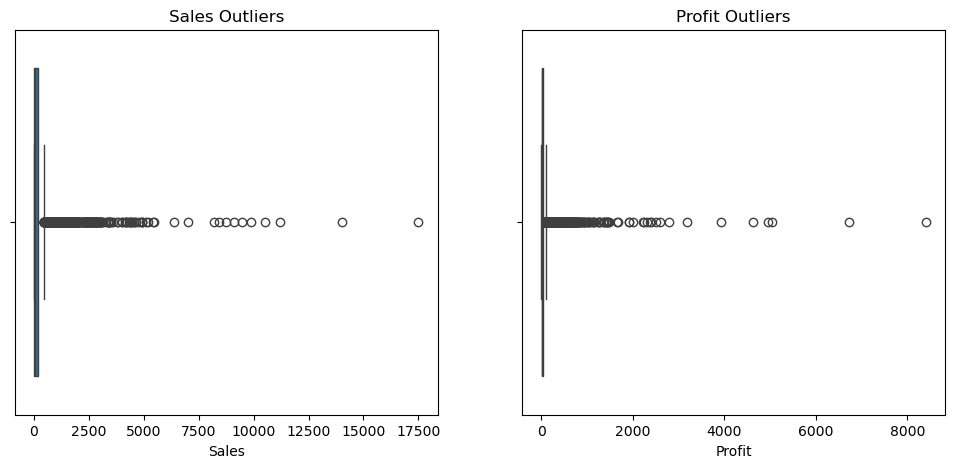

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots to visualize outliers
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Sales"])
plt.title("Sales Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df["Profit"])
plt.title("Profit Outliers")

plt.show()

In [21]:
df = df[(df["Sales"] < df["Sales"].quantile(0.99))]
df = df[(df["Profit"] < df["Profit"].quantile(0.99))]

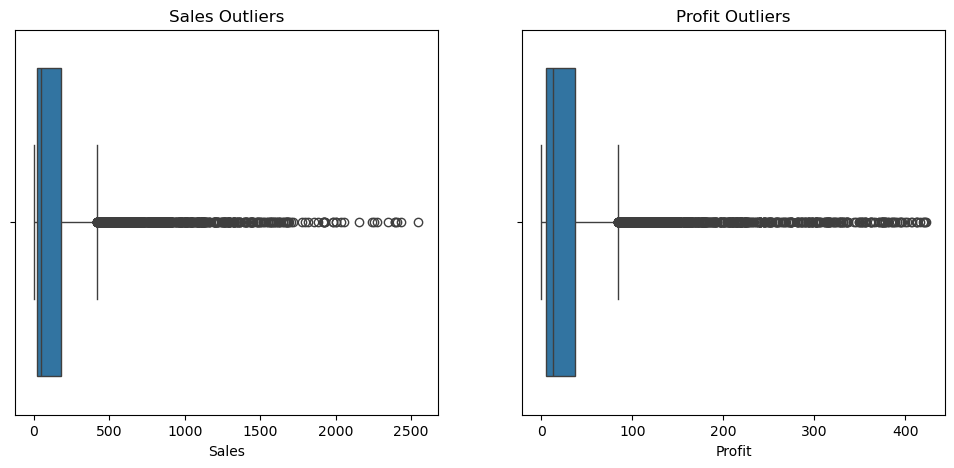

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots to visualize outliers
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Sales"])
plt.title("Sales Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df["Profit"])
plt.title("Profit Outliers")

plt.show()

In [25]:
print("Negative Profit Rows:", df[df["Profit"] < 0].shape[0])

Negative Profit Rows: 0


In [74]:
df_filtered = df[df["Profit"] >= 0]

In [76]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [78]:
df['Category'] = df['Category'].str.strip().str.title()
df['Sub-Category'] = df['Sub-Category'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.title()

In [80]:
top_products = df.groupby("Product Name")["Profit"].sum().nlargest(5)
print(top_products)

Product Name
Sharp 1540cs Digital Laser Copier            1649.9700
GBC DocuBind TL200 Manual Binding Machine    1644.0132
Dual Level, Single-Width Filing Carts        1640.5348
Tennsco 6- and 18-Compartment Lockers        1622.8404
Hot File 7-Pocket, Floor Stand               1534.8420
Name: Profit, dtype: float64


In [82]:
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


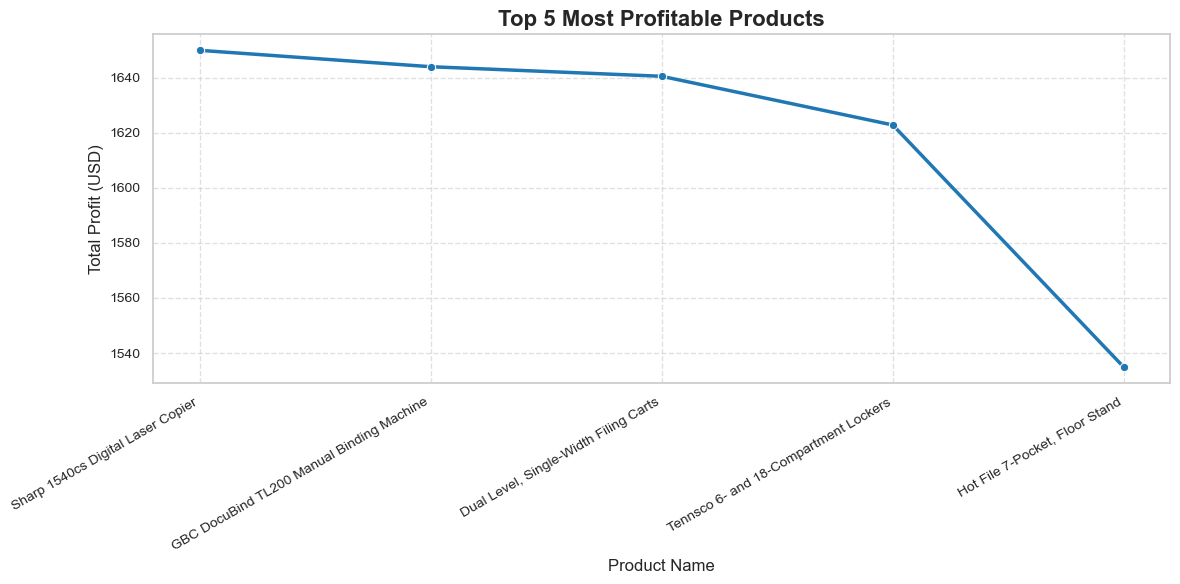

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
top_products = df.groupby("Product Name")["Profit"].sum().nlargest(5)
product_names = top_products.index
profits = top_products.values

# Set Seaborn theme
sns.set_theme(style="whitegrid")

# Create the figure and axis
plt.figure(figsize=(12, 6))
sns.lineplot(x=product_names, y=profits, marker='o', linewidth=2.5, color="#1f77b4")

# Titles and labels
plt.title("Top 5 Most Profitable Products", fontsize=16, fontweight='bold')
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Total Profit (USD)", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show plot
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_13076\876571374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette="coolwarm")


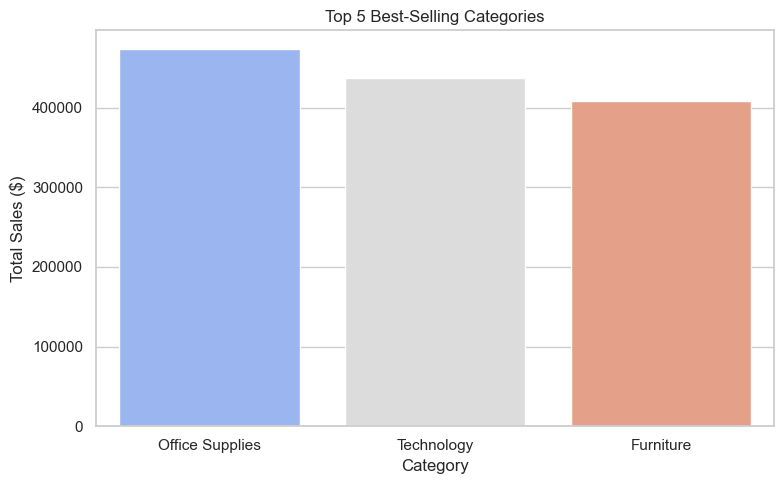

In [46]:
top_categories = df.groupby("Category")["Sales"].sum().nlargest(5)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_categories.index, y=top_categories.values, palette="coolwarm")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.title("Top 5 Best-Selling Categories")
plt.tight_layout()
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_13076\3621141348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma")


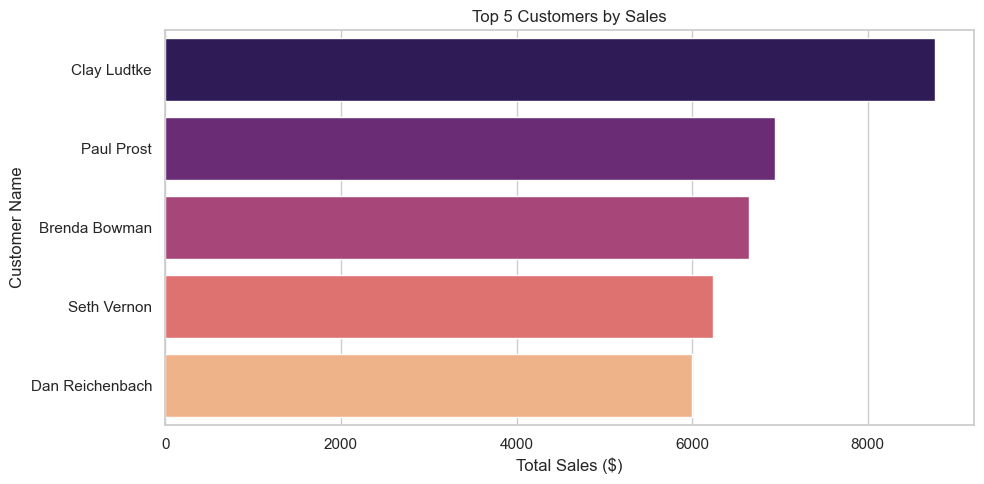

In [48]:
top_customers = df.groupby("Customer Name")["Sales"].sum().nlargest(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="magma")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer Name")
plt.title("Top 5 Customers by Sales")
plt.tight_layout()
plt.show()

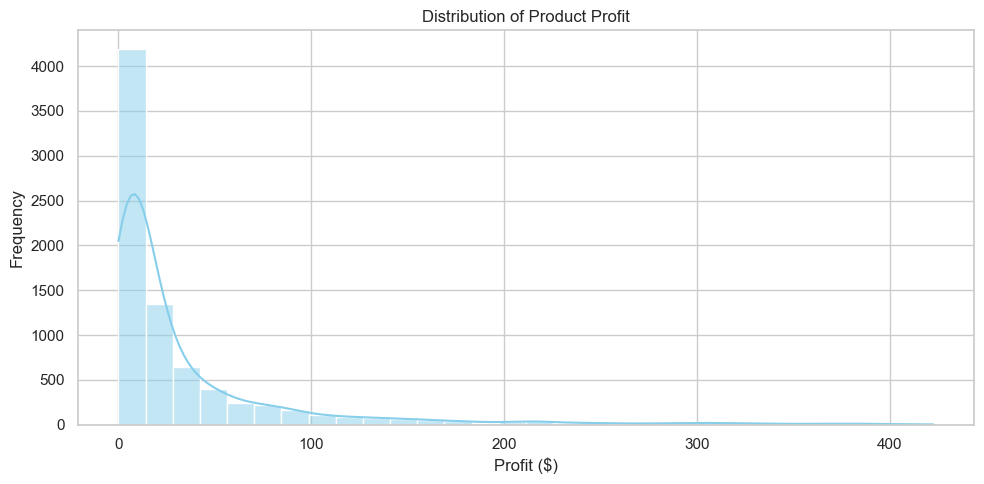

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Profit"], bins=30, kde=True, color="skyblue")
plt.xlabel("Profit ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Product Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

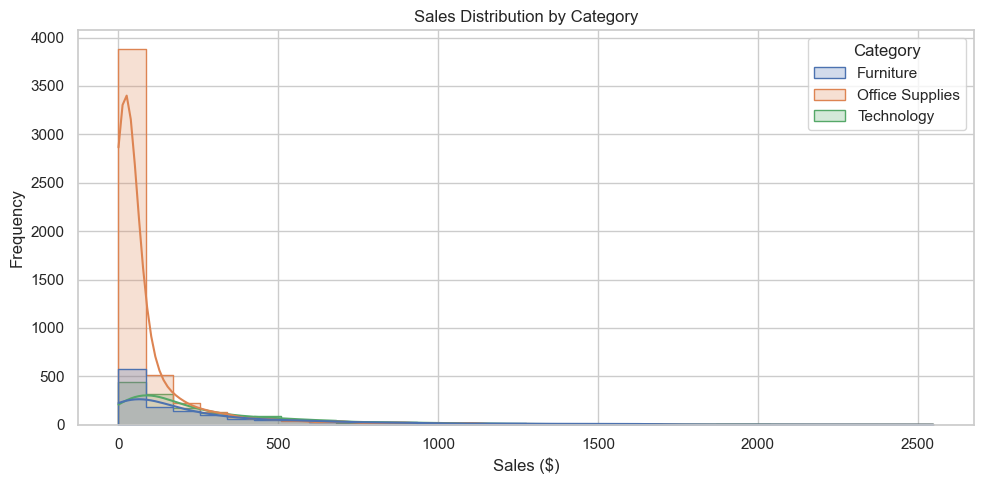

In [52]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Sales", hue="Category", bins=30, element="step", kde=True)
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.title("Sales Distribution by Category")
plt.grid(True)
plt.tight_layout()
plt.show()

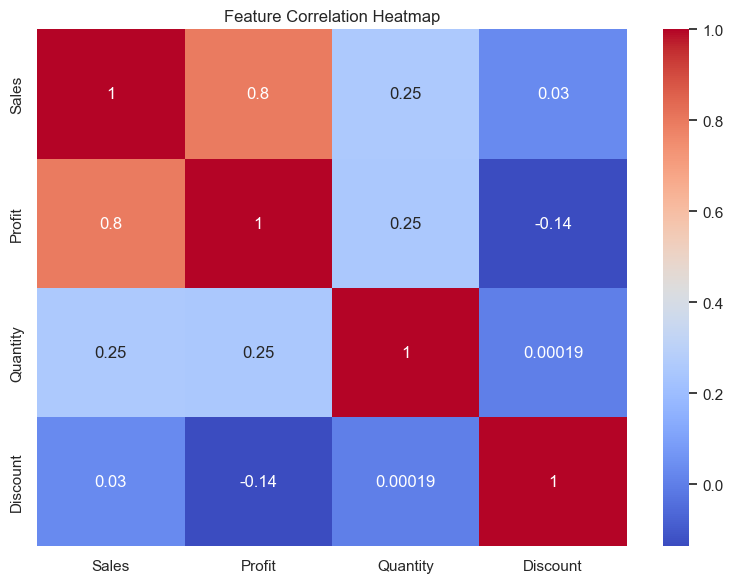

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Sales', 'Profit', 'Quantity', 'Discount']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

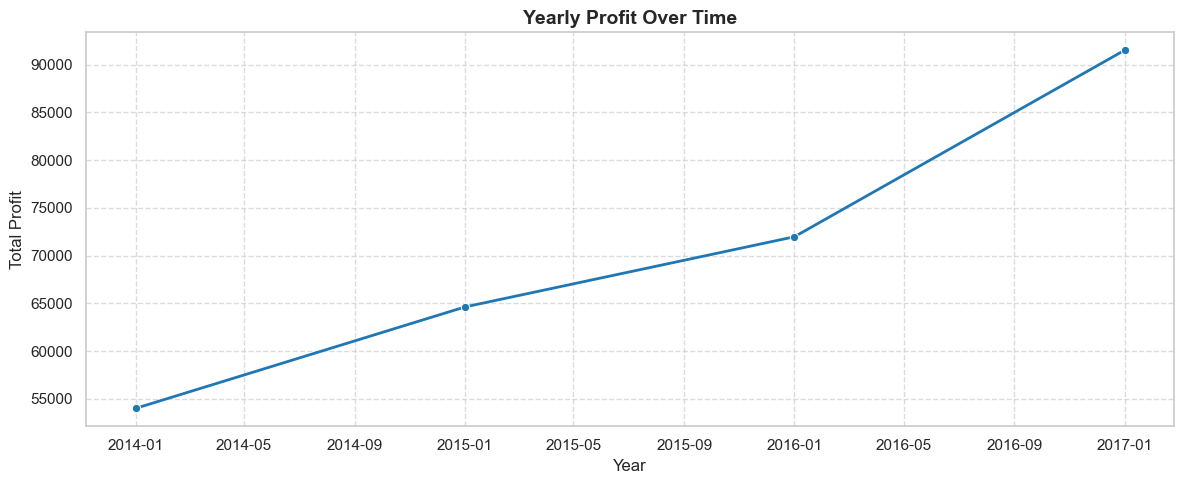

In [58]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Group by year instead of month
df_yearly = df.groupby(df['Order Date'].dt.to_period('Y'))['Profit'].sum().reset_index()
df_yearly['Order Date'] = df_yearly['Order Date'].dt.to_timestamp()

# Plot yearly profit
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_yearly, x="Order Date", y="Profit", marker="o", linewidth=2, color="#1f77b4")
plt.title("Yearly Profit Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Select features and target
features = df[['Sales', 'Quantity', 'Discount']]
target = df['Profit']

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create pipeline
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train model
model_pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = model_pipeline.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")


R² Score: 0.69
MSE: 1086.95


In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Select features and target variable
features = df[['Sales', 'Quantity', 'Discount']]
target = df['Profit']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# Loop through models and evaluate
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f" {name}")
    print(f"  R² Score: {r2:.3f}")
    print(f"  MSE: {mse:.2f}")
    print("-" * 30)


 Linear Regression
  R² Score: -0.724
  MSE: 83592.67
------------------------------
 Random Forest
  R² Score: -0.279
  MSE: 62026.69
------------------------------
 KNN Regressor
  R² Score: -0.255
  MSE: 60870.58
------------------------------


In [101]:
from sklearn.model_selection import cross_validate, KFold

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Store cross-validation results
cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    
    scores = cross_validate(
        pipeline, X=features, y=target,
        cv=cv,
        scoring=('r2', 'neg_mean_squared_error'),
        return_train_score=False
    )
    
    cv_results.append({
        'Model': name,
        'Mean R²': scores['test_r2'].mean(),
        'Mean MSE': -scores['test_neg_mean_squared_error'].mean()
    })

# Create DataFrame of cross-validation results
cv_df = pd.DataFrame(cv_results)
print(cv_df)


               Model   Mean R²      Mean MSE
0  Linear Regression  0.152557  45412.190170
1      Random Forest  0.617372  19931.556651
2      KNN Regressor  0.469802  30243.823590
